# Leaf water as a tracer of plant water source — proof of concept (Colab reproduction)

**Paper:** Benettin P., Nehemy M. F., Cernusak L. A., Kahmen A., McDonnell J. J. (2021).
*On the use of leaf water to determine plant water source: A proof of concept.*
Hydrological Processes 35(3), e14073. [doi:10.1002/hyp.14073](https://doi.org/10.1002/hyp.14073)

**Author code:** [pbenettin/Leaf_water_source](https://github.com/pbenettin/Leaf_water_source),
commit `c495e14ddbd4b81d5ffd35fe96e41e58c85f8fff`, MIT license (MATLAB).

**Purpose.** During the SPIKE II vegetated-lysis experiment (willows, EPFL, 10 May–29 Jun 2018) the
authors measured δ¹⁸O and δ²H of xylem and leaf water and used a Craig-Gordon evaporation model to
project each sample back onto the local meteoric water line (LMWL), tracing which rainfall the plant
took up. This notebook re-runs that source apportionment: (1) a Monte Carlo Craig-Gordon model
(10 000 parameter combinations per sample) gives evaporation-line slope distributions; (2) a
rejection sampler (adapted from Bowen et al. 2018) projects every xylem and leaf sample onto the
LMWL with uncertainty; (3) leaf-minus-xylem projected-source residuals are compared with the
author's reported values (mean ≈ 2.3‰ in δ²H; std ≈ 0.8‰ δ¹⁸O, 6.9‰ δ²H).

**Scope.** Partial demonstration: the full per-sample pipeline on the released SPIKE II isotope and
meteorological data, plus the paper's two-sample theory example. Benchmark-level claims and the
paper's full text (Wiley, not openly retrievable here) are out of scope.

**Execution status:** executed on Google Colab (CPU runtime); outputs below are from a fresh run.

> **AI-assisted translation from MATLAB.** The authors did not provide this Colab implementation.
> All equations are copied verbatim from the pinned commit; the executed example and listed checks
> were validated, but untested behavior is not guaranteed. (日本語) 本notebookはMATLABコードのAIによる移植です。数式は原著リポジトリからそのまま写していますが、未検証の挙動については保証されません。

(日本語) このnotebookは、SPIKE II実験の同位体データを用いて、葉水から植物の吸水源を推定する
原著論文の解析をColab上で再実行するものです。Craig-Gordonモデルのモンテカルロ計算とLMWLへの
確率的投影、葉水・木部水の残差比較を行います。

## Runtime selection — CPU is sufficient

This is a lightweight scalar Monte Carlo (≈100 samples × 10 000 Craig-Gordon evaluations plus a
small rejection sampler). No GPU, no deep-learning framework, and no large downloads are involved
(total downloads < 0.5 MB). **Select Runtime → Change runtime type → CPU** (the default is fine),
then **Runtime → Run all**. Expected wall time: ≲ 5 minutes on the free tier.

(日本語) 軽量なモンテカルロ計算のためGPUは不要です。ランタイムはCPUのままで「すべてのセルを実行」してください。所要時間は5分以内程度です。

In [ ]:
import sys, numpy as np, scipy, pandas as pd, matplotlib
import matplotlib.pyplot as plt
print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| scipy", scipy.__version__,
      "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

# The author's MATLAB code is unseeded; we fix a seed so this notebook is reproducible.
# (MATLAB乱数とは異なります。統計的手続きは同一です。)
SEED = 42
np.random.seed(SEED)
print("numpy random seed:", SEED)

Python 3.13.16
numpy 2.1.3 | scipy 1.16.3 | pandas 2.2.3 | matplotlib 3.10.0
numpy random seed: 42


## Data acquisition (inside Colab only)

Two small input files are needed, both public:

1. **`spike.isotope.II.csv`** — the SPIKE II dual-isotope dataset (δ¹⁸O, δ²H of >900 water samples),
   from the paper-cited Zenodo record [4037240](https://zenodo.org/records/4037240) (CC-BY-4.0).
   We query the record API at runtime, take the file's returned download link, and verify size
   (52 564 B) and MD5 (`e75d4a0e…`) recorded from the record metadata.
2. **`meteodata_EPFL.csv`** — EPFL campus meteorology (air temperature, relative humidity), which
   ships only inside the author repository (`data/` folder). We fetch it from the pinned commit
   `c495e14…` on raw.githubusercontent.com and verify the git blob SHA-1
   (`476fa872…`, 366 289 B) computed from the pinned tree metadata.

(日本語) 同位体データはZenodoレコード4037240から、気象データは著者リポジトリの固定コミットから
取得します。それぞれMD5/git blob SHA-1で完全性を検証します。

In [ ]:
import hashlib, json, pathlib, urllib.request

def http_get(url, timeout=120):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-reproduction-notebook"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.read()

# --- 1) SPIKE II isotope table from the paper-cited Zenodo record -----------------
rec = json.loads(http_get("https://zenodo.org/api/records/4037240"))
f = next(f for f in rec["files"] if f["key"] == "spike.isotope.II.csv")
iso_bytes = http_get(f["links"]["self"])
assert len(iso_bytes) == 52564, f"unexpected size {len(iso_bytes)}"
assert hashlib.md5(iso_bytes).hexdigest() == "e75d4a0e0949f5a9b42879016976338c", "MD5 mismatch"
pathlib.Path("spike.isotope.II.csv").write_bytes(iso_bytes)
print("spike.isotope.II.csv:", len(iso_bytes), "bytes, MD5 ok (Zenodo record 4037240)")

spike.isotope.II.csv: 52564 bytes, MD5 ok (Zenodo record 4037240)


**`meteodata_EPFL.csv`** — EPFL campus meteorology, which ships only inside the author repository
(`data/` folder; the Zenodo record does not contain a meteorological file). We fetch it from the
pinned commit `c495e14…` on raw.githubusercontent.com and verify the git blob SHA-1
(`476fa872…`, 366 289 B) computed from the pinned tree metadata.

(日本語) 気象データはZenodoには無いため、著者リポジトリの固定コミットから取得し、git blob
SHA-1で検証します。

In [ ]:
# --- 2) EPFL meteorology from the pinned author repository commit -----------------
REPO_COMMIT = "c495e14ddbd4b81d5ffd35fe96e41e58c85f8fff"
METEO_URL = ("https://raw.githubusercontent.com/pbenettin/Leaf_water_source/"
             + REPO_COMMIT + "/data/meteodata_EPFL.csv")
meteo_bytes = http_get(METEO_URL)
# git blob SHA-1 of the pinned file (tree metadata): sha1("blob <size>\0" + content)
blob_sha1 = hashlib.sha1(b"blob %d\x00" % len(meteo_bytes) + meteo_bytes).hexdigest()
assert len(meteo_bytes) == 366289, f"unexpected size {len(meteo_bytes)}"
assert blob_sha1 == "476fa8729be251a50daa3a91ac11f38516f012e2", f"blob SHA-1 mismatch: {blob_sha1}"
pathlib.Path("meteodata_EPFL.csv").write_bytes(meteo_bytes)
print("meteodata_EPFL.csv:", len(meteo_bytes), "bytes, git blob SHA-1 ok (commit", REPO_COMMIT[:8], ")")

meteodata_EPFL.csv: 366289 bytes, git blob SHA-1 ok (commit c495e14d )


## Input preview

Before any analysis, inspect the actual downloaded bytes: the isotope table (columns, sample types,
date coverage) and the meteorological record (air temperature T in °C, relative humidity rh in %).
The isotope file is read exactly like the author's `readtable(...,'TreatAsEmpty','NA')`; the meteo
file like `readtable(...,'HeaderLines',4)` (first 4 lines skipped, header on line 5 → pandas
`skiprows=4`).

(日本語) まずダウンロードしたデータの中身を確認します。同位体表と気象記録の列名・期間・行数を表示します。

In [ ]:
iso_raw = pd.read_csv("spike.isotope.II.csv", na_values=["NA"])
print("isotope table shape:", iso_raw.shape)
print("columns:", list(iso_raw.columns))
expected = {"TIMESTAMP", "Type", "d18O.UoS", "d2H.UoS"}
missing = expected - set(iso_raw.columns)
assert not missing, f"isotope table missing expected columns {missing}; found {list(iso_raw.columns)}"
print(iso_raw.head(3).to_string())
print("...")
print("Type value counts (raw):")
print(iso_raw["Type"].value_counts().to_string())

isotope table shape: (728, 12)
columns: ['ID', 'Type', 'Depth', 'Sector', 'Branch', 'TIMESTAMP', 'Date', 'Input.volume', 'd18O.UoS', 'd2H.UoS', 'd18O.EPFL', 'd2H.EPFL']
   ID        Type  Depth Sector Branch         TIMESTAMP        Date  Input.volume  d18O.UoS  d2H.UoS  d18O.EPFL  d2H.EPFL
0  57  Soil Water   50.0      A    NaN  2018-03-01 10:00  2018-03-01           NaN       NaN      NaN      -9.52    -68.13
1  58  Soil Water   50.0      B    NaN  2018-03-01 10:00  2018-03-01           NaN       NaN      NaN     -10.64    -78.75
2  59  Soil Water   50.0      C    NaN  2018-03-01 10:00  2018-03-01           NaN       NaN      NaN     -10.40    -78.94
...
Type value counts (raw):
Type
Soil Water                            358
Soil                                  130
Xylem                                  41
Leakage Flow                           37
Leaves                                 25
Precipitation                          22
Soil profile 3                         20
Soil profil

### Meteorology preview

Plot the actual downloaded meteorology (air temperature T in °C on the left axis, relative humidity
rh in % on the right). These are the covariates for the Craig-Gordon parameter ranges (24-h and
30-day averages).

(日本語) 気象データ（気温・相対湿度）の実データをプロットして確認します。

meteo table shape: (14305, 3)
columns: ['time', 'T', 'rh']
meteo period: 2018-02-05 00:00:00 → 2018-07-04 00:00:00


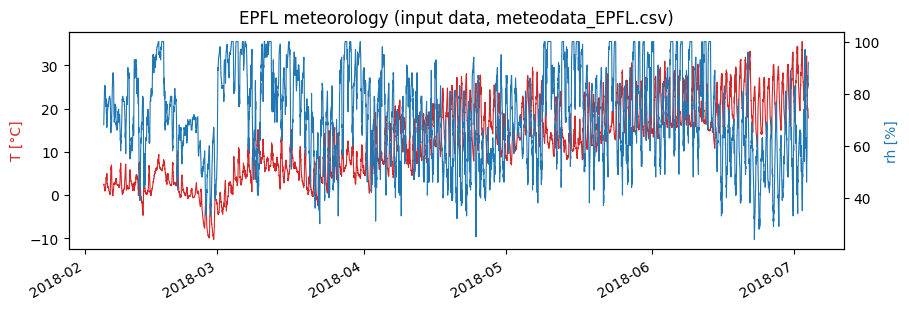

In [ ]:
meteo_raw = pd.read_csv("meteodata_EPFL.csv", skiprows=4)
print("meteo table shape:", meteo_raw.shape)
print("columns:", list(meteo_raw.columns))
for c in ("time", "T", "rh"):
    assert c in meteo_raw.columns, f"meteo table missing column {c!r}; found {list(meteo_raw.columns)}"
meteo_raw["time"] = pd.to_datetime(meteo_raw["time"])
print("meteo period:", meteo_raw["time"].min(), "→", meteo_raw["time"].max())

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(meteo_raw["time"], meteo_raw["T"], color="tab:red", lw=0.8, label="air temperature T [°C]")
ax.set_ylabel("T [°C]", color="tab:red")
ax2 = ax.twinx()
ax2.plot(meteo_raw["time"], meteo_raw["rh"], color="tab:blue", lw=0.8, label="relative humidity rh [%]")
ax2.set_ylabel("rh [%]", color="tab:blue")
ax.set_title("EPFL meteorology (input data, meteodata_EPFL.csv)")
fig.autofmt_xdate()
plt.show()

The dual-isotope input space: every raw isotope sample plotted in δ¹⁸O–δ²H space, with the LMWL
used later (slope 8.27, intercept 11.41, from the author's main script line 115) for reference.
Leaf water is expected to plot to the **right** of the LMWL (evaporative enrichment).

(日本語) 全同位体試料のδ¹⁸O–δ²H二重同位体プロット。破線は後で使うLMWLです。葉水は蒸発濃縮によりLMWLの右側にプロットされるはずです。

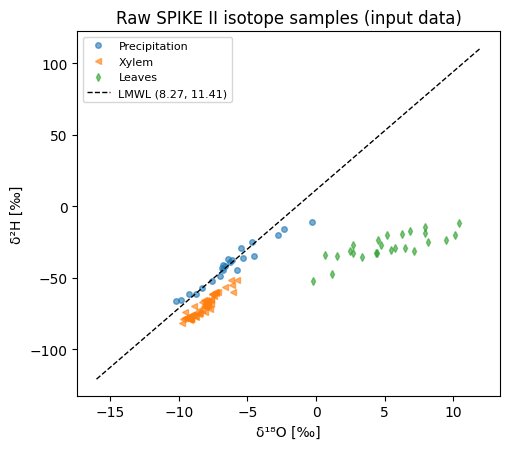

In [ ]:
fig, ax = plt.subplots(figsize=(5.2, 4.6))
for typ, marker, color in [("Precipitation", "o", "tab:blue"), ("Xylem", "<", "tab:orange"),
                           ("Leaves", "d", "tab:green")]:
    m = iso_raw["Type"].astype(str).str.contains(typ, na=False)
    if m.any():
        ax.plot(iso_raw.loc[m, "d18O.UoS"], iso_raw.loc[m, "d2H.UoS"], marker, ms=4,
                color=color, alpha=0.6, ls="none", label=typ)
xx = np.array([-16, 12])
ax.plot(xx, 8.27 * xx + 11.41, "k--", lw=1, label="LMWL (8.27, 11.41)")
ax.set_xlabel("δ¹⁸O [‰]"); ax.set_ylabel("δ²H [‰]")
ax.set_title("Raw SPIKE II isotope samples (input data)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Preprocessing — port of `data_load_and_process.m`

The author's preprocessing (exact port): keep only **Xylem** (regex-matched types renamed to
`Xylem`) and **Leaves** sampled after **2018-05-08**; assign a `datecount` index grouping samples
collected within **1 hour** of each other; then append meteorological covariates averaged over the
**previous 24 h** (`Tday`, `rhday`; relevant for leaf water, evaporation over hours–days) and the
**previous 30 days** (`Tmonth`, `rhmonth`; relevant for xylem water, soil evaporation over
weeks–months), exactly as in `Leaf_water_source.m` lines 100–105.

(日本語) 前処理は著者コードの正確な移植です。2018-05-08以降のXylem/Leavesのみを残し、1時間以内の
試料を同じdatecountにまとめ、直近24時間（葉水用）と30日間（木部水用）の気象平均を付与します。

In [ ]:
def data_load_and_process():
    """Exact port of functions/data_load_and_process.m @ c495e14."""
    # load plant isotope data (TreatAsEmpty 'NA'); the file header uses dotted names
    # (d18O.UoS / d2H.UoS, verified in Colab) which MATLAB readtable exposed as d18O_UoS
    T = pd.read_csv("spike.isotope.II.csv", na_values=["NA"])
    T = T.rename(columns={k: v for k, v in
                          {"TIMESTAMP": "time", "d18O.UoS": "d18O", "d2H.UoS": "d2H",
                           "d18O_UoS": "d18O", "d2H_UoS": "d2H"}.items() if k in T.columns})
    # simplify type labels: anything containing 'Xylem' becomes 'Xylem'
    T["Type"] = T["Type"].astype(str)
    T.loc[T["Type"].str.contains("Xylem", na=False), "Type"] = "Xylem"
    # keep xylem and leaf samples after 08-May-2018
    T["time"] = pd.to_datetime(T["time"])
    q = (T["time"] > pd.Timestamp("2018-05-08")) & T["Type"].isin(["Xylem", "Leaves"])
    T = T.loc[q, ["Type", "time", "d18O", "d2H"]].reset_index(drop=True)

    # index of unique sampling times (tolerance: 1 hour)
    diffthresh = 1  # hours
    ts = T["time"].values
    order = np.argsort(ts, kind="stable")              # [tmpval, tmpind] = sort(...)
    isuni = np.diff(ts[order]) > np.timedelta64(diffthresh * 3600, "s")
    icsorted = np.cumsum(np.concatenate([[True], isuni]))  # cumsum([1; isuni])
    datecount = np.empty(len(ts), dtype=int)
    datecount[order] = icsorted
    T["datecount"] = datecount

    # meteorology: averages over delt1=24h and delt2=30d prior to sampling
    meteo = pd.read_csv("meteodata_EPFL.csv", skiprows=4)
    meteo["time"] = pd.to_datetime(meteo["time"])
    mt = meteo["time"].values
    mT, mrh = meteo["T"].values.astype(float), meteo["rh"].values.astype(float)
    tt = T["time"].values
    day, month = np.timedelta64(1, "D"), np.timedelta64(30, "D")
    T["Tday"] = [mT[(mt >= t - day) & (mt <= t)].mean() for t in tt]
    T["rhday"] = [mrh[(mt >= t - day) & (mt <= t)].mean() for t in tt]
    T["Tmonth"] = [mT[(mt >= t - month) & (mt <= t)].mean() for t in tt]
    T["rhmonth"] = [mrh[(mt >= t - month) & (mt <= t)].mean() for t in tt]
    assert T[["Tday", "rhday", "Tmonth", "rhmonth"]].notna().all().all(), \
        "meteorological averaging produced NaN (no meteo coverage for some sample time)"
    return T

T = data_load_and_process()
print("samples kept:", len(T))
print(T["Type"].value_counts().to_string())
print("period:", T["time"].min(), "→", T["time"].max())
print("sampling days (datecount groups):", T["datecount"].nunique())
T.head(5)

samples kept: 84
Type
Xylem     59
Leaves    25
period: 2018-05-08 12:30:00 → 2018-06-29 14:00:00
sampling days (datecount groups): 41


,Type,time,d18O,d2H,datecount,Tday,rhday,Tmonth,rhmonth
0,Xylem,2018-05-08 12:30:00,-9.18,-78.28,1,18.711237,58.134021,15.584495,63.413745
1,Xylem,2018-05-08 12:30:00,-9.18,-78.28,1,18.711237,58.134021,15.584495,63.413745
2,Xylem,2018-05-08 12:30:00,-9.18,-78.28,1,18.711237,58.134021,15.584495,63.413745
3,Xylem,2018-05-16 14:00:00,-9.55,-73.89,2,11.654639,94.824742,15.867560,68.228740
4,Xylem,2018-05-17 14:00:00,-7.61,-61.70,3,13.685773,85.969072,15.819417,68.942728


## Craig-Gordon evaporation line — port of `f_fractionation_CraigGordon_slim.m`

For one parameter set `[n, hm, Tc, k]` (aerodynamic regime, relative humidity, temperature,
atmosphere disequilibrium factor) the function computes equilibrium fractionations
(Horita & Wesolowski 1994), kinetic fractionations (Merlivat 1978 diffusivities, Horita et al. 2008
approach), the atmospheric vapor composition from the precipitation-equilibrium assumption
(Gibson et al. 2008), the enrichment slope `m` and limiting composition `dstar`
(Gonfiantini 1986), and finally the **slope of the evaporation line** connecting the source water to
the steady-state/asymptotic composition (flag_method 2 = lake/soil reaching steady state).
All equations are copied verbatim from the pinned file; note that `x` is a 2-element vector and the
function returns the slope for `x(end)` exactly as the MATLAB code does (`ds_H(end)-dp_H`).

(日本語) Craig-Gordonモデルの実装です。平衡・速度論的同位体分別、大気水蒸気組成、濃縮勾配mと
極限組成dstarを計算し、蒸発線の傾きを返します。数式は原著関数からの逐語移植です。

In [ ]:
def f_fractionation_CraigGordon_slim(inputpar, iso_source, flag_method, x):
    """Exact port of functions/f_fractionation_CraigGordon_slim.m @ c495e14.
    inputpar = [n, hm, Tc, k]; iso_source = [d18O, d2H] of source water; x may be a vector,
    the slope uses the last element (MATLAB ds(end))."""
    n, hm, Tc, k = [float(v) for v in inputpar]
    theta = 1.0                       # atmospheric feedback factor (no feedback)
    Dr_H, Dr_O = 0.9755, 0.9723       # diffusivity ratios, Merlivat 1978
    dp_O, dp_H = float(iso_source[0]), float(iso_source[1])

    Tk = Tc + 273.15
    # equilibrium fractionation factors, Horita and Wesolowski (1994)
    alphae_H = np.exp(1/1000 * (1158.8 * Tk**3 / 1e9 - 1620.1 * Tk**2 / 1e6
                                + 794.84 * Tk / 1e3 - 161.04 + 2.9992e9 / Tk**3))
    alphae_O = np.exp(1/1000 * (-7.685 + 6.7123e3 / Tk - 1.6664e6 / Tk**2 + 0.3504e9 / Tk**3))
    epse_H, epse_O = (alphae_H - 1) * 1000, (alphae_O - 1) * 1000   # permil

    # kinetic fractionation factors (Horita et al. 2008)
    epsk_H = n * theta * (1 - Dr_H) * 1000 * (1 - hm)
    epsk_O = n * theta * (1 - Dr_O) * 1000 * (1 - hm)

    # atmospheric composition from precipitation-equilibrium assumption (Gibson et al., 2008)
    da_H = (dp_H - k * epse_H) / (1 + k * epse_H * 1e-3)
    da_O = (dp_O - k * epse_O) / (1 + k * epse_O * 1e-3)

    # enrichment slope m and limiting isotopic composition dstar (Gonfiantini 1986)
    m_H = (hm - 1e-3 * (epsk_H + epse_H / alphae_H)) / (1 - hm + 1e-3 * epsk_H)
    m_O = (hm - 1e-3 * (epsk_O + epse_O / alphae_O)) / (1 - hm + 1e-3 * epsk_O)
    dstar_H = (hm * da_H + epsk_H + epse_H / alphae_H) / (hm - 1e-3 * (epsk_H + epse_H / alphae_H))
    dstar_O = (hm * da_O + epsk_O + epse_O / alphae_O) / (hm - 1e-3 * (epsk_O + epse_O / alphae_O))

    x = np.atleast_1d(np.asarray(x, dtype=float))
    if flag_method == 1:      # desiccating water body
        ds_H = (dp_H - dstar_H) * (1 - x) ** m_H + dstar_H
        ds_O = (dp_O - dstar_O) * (1 - x) ** m_O + dstar_O
    elif flag_method == 2:    # lake/soil reaching steady state
        ds_H = (x * m_H * dstar_H + dp_H) / (1 + m_H * x)
        ds_O = (x * m_O * dstar_O + dp_O) / (1 + m_O * x)
    else:
        raise ValueError("flag_method must be 1 or 2")
    # slope of the evaporation line connecting source and end point (MATLAB: ds(end))
    return (ds_H[-1] - dp_H) / (ds_O[-1] - dp_O)

### Monte Carlo wrapper — port of `montecarloCG.m`

A plain nested loop over the four parameter lists (kept loop-for-loop like the author's code; the
inner call is scalar). Humidity is given in %, clipped at 0.98 to avoid numerically problematic
99–100% values, exactly as in the author's wrapper.

(日本語) 4つのパラメータ範囲の全組み合わせ（ここでは10⁴通り）についてCraig-Gordon計算を繰り返し、
蒸発線の傾きの分布を作ります。湿度は%から小数に変換し0.98でクリップします。

In [ ]:
def montecarloCG(n_list, hr_list, T_list, k_list, iso_source, flag_method, x):
    """Exact port of functions/montecarloCG.m @ c495e14 (nested loops over parameter lists)."""
    N = len(n_list) * len(hr_list) * len(T_list) * len(k_list)
    sl = np.zeros(N)
    nn = 0
    for n in n_list:
        for hr in hr_list:
            for Tc in T_list:
                for k in k_list:
                    nn += 1
                    hr_perc = min(hr / 100, 0.98)  # avoid 99-100% (numerically problematic)
                    sl[nn - 1] = f_fractionation_CraigGordon_slim(
                        [n, hr_perc, Tc, k], iso_source, flag_method, x)
    return sl

## LMWL source sampler — port of `source_sampler_iter.m` (+ `project_dualisotope`)

The sampler is adapted by the author from the SPATIAL-Lab `watercompare` R code (Bowen et al.
2018): repeat until `ngens` accepted draws — (1) perturb the measured sample with its uncertainty
(bivariate normal, `d_o_par` = [std δ¹⁸O, std δ²H, correlation]); (2) draw a candidate source
uniformly between the two extreme evaporation-line projections onto the LMWL, with δ²H scattered
around the LMWL (`sigma_H_lmwl`); (3) accept the candidate with probability equal to the ratio of
its connecting-line slope probability (fitted evaporation-slope distribution) to the distribution
maximum (Metropolis-style rejection). The slope distribution objects mimic MATLAB's `makedist` /
`fitdist('LogNormal')`: for a lognormal fit MATLAB uses `mu = mean(log(sl))`,
`sigma = std(log(sl))` (n−1 normalization), matching `scipy.stats.lognorm(s=sigma, scale=exp(mu))`.

(日本語) 観測試料の不確実性、LMWL上の候補水源、蒸発線傾きの確率に基づく棄却サンプリングで、
各試料のLMWL上の水源分布を生成します。対数正規分布の当てはめはMATLABのfitdistと同じ
（log(sl)の平均・不偏標準偏差）です。

In [ ]:
from scipy import stats

def fit_lognormal(sl):
    """MATLAB fitdist(sl,'LogNormal'): mu=mean(log x), sigma=std(log x) (n-1)."""
    mu, sigma = np.mean(np.log(sl)), np.std(np.log(sl), ddof=1)
    return stats.lognorm(s=sigma, scale=np.exp(mu))

def project_dualisotope(datain, coef_mixwl, coef_evapl):
    """Exact port of the local helper in source_sampler_iter.m: project points in dual-isotope
    space onto the mixing line (pm) and the evaporation line (pe)."""
    sl_m, y0_m = float(coef_mixwl[0]), float(coef_mixwl[1])
    sl_e, y0_e = float(coef_evapl[0]), float(coef_evapl[1])
    Am1 = 1 / (sl_m - sl_e) * np.array([[-1, 1], [-sl_m, sl_e]])
    Bm1 = 1 / (sl_e - sl_m) * np.array([[-1, 1], [-sl_e, sl_m]])
    datain = np.atleast_2d(np.asarray(datain, dtype=float))
    pm, pe = np.zeros_like(datain), np.zeros_like(datain)
    for i in range(datain.shape[0]):
        xA, yA = datain[i]
        pm[i] = Am1 @ np.array([sl_e * xA - yA, -y0_m])
        pe[i] = Bm1 @ np.array([sl_m * xA - yA, -y0_e])
    return pm, pe

def source_sampler_iter(d_o, d_o_par, lmwl_par, sigma_H_lmwl, el_distr, ngens):
    """Exact port of functions/source_sampler_iter.m @ c495e14.
    d_o = [d18O, d2H] of the measured sample; d_o_par = [std d18O, std d2H, correlation];
    lmwl_par = [slope, intercept]; sigma_H_lmwl = std of d2H around the LMWL;
    el_distr = frozen scipy distribution of evaporation-line slopes; ngens = accepted draws.
    Returns A (ngens x 6): [source d18O, source d2H, sample d18O, sample d2H, slope, slope pdf]."""
    sigma_H_h = sigma_H_lmwl
    A = np.full((ngens, 6), np.nan)
    maxiter, it, n = 100000, 1, 1
    d_o = np.asarray(d_o, dtype=float)
    if np.any(np.isnan(d_o)):
        return A
    # credible range for the O source: intersect the sample with very flat/steep evaporation lines
    stdfactor = 4
    el_mean, el_std = float(el_distr.mean()), float(el_distr.std())
    pmhigh, _ = project_dualisotope(d_o, lmwl_par, [el_mean - stdfactor * el_std, 1000])
    pmlow, _ = project_dualisotope(d_o, lmwl_par, [min(el_mean + stdfactor * el_std, lmwl_par[0] - 0.01), 1000])
    if pmhigh[0, 0] < pmlow[0, 0]:
        print("sample lies left of mixing line...")
        return A
    # maximum of the slope pdf (needed for the Metropolis test)
    xs = np.linspace(el_mean - el_std, el_mean + el_std, 1000)
    max_Sprob = float(el_distr.pdf(xs).max())
    while n <= ngens:
        # 1 - observation: uncertainty around the measurement
        SIGMA = [[d_o_par[0]**2, d_o_par[0] * d_o_par[1] * d_o_par[2]],
                 [d_o_par[0] * d_o_par[1] * d_o_par[2], d_o_par[1]**2]]
        X_o = np.random.multivariate_normal([d_o[0], d_o[1]], SIGMA, size=1)
        # 2 - candidate source within the credible range, on the LMWL
        O_h = pmlow[0, 0] + np.random.rand() * (pmhigh[0, 0] - pmlow[0, 0])
        H_h = np.random.normal(lmwl_par[0] * O_h + lmwl_par[1], sigma_H_h)
        # 3 - accept/reject according to the slope probability
        S = (X_o[0, 1] - H_h) / (X_o[0, 0] - O_h)
        Sprob = float(el_distr.pdf(S))
        if Sprob > max_Sprob * 1.01:
            raise RuntimeError("The maximum slope probability was not accurate enough. "
                               "Increase the variable N around line 50")
        if Sprob > max_Sprob * np.random.rand():
            A[n - 1] = [O_h, H_h, X_o[0, 0], X_o[0, 1], S, Sprob]
            n += 1
        it += 1
        if it > maxiter:
            print(f"Attention: only {n - 1}/{ngens} samples extracted in {maxiter} iterations")
            A[n - 1:] = np.nan
            break
    return A

### Sanity check of the Craig-Gordon port: evaporation-line slope distributions

Re-creating the author's `generate_fig_el_slopes.m`: for the two days used there
(14-Jun-2018 14:15 and 26-Jun-2018 13:15), run the 10 000-combination Monte Carlo for the xylem
(30-day meteorology, `n_list_s` 0.75–1, `x_s=[0,0.3]`) and leaf (24-h meteorology, `n_list_l`
0.85–1, `x_l=[0,1]`) samples and overlay the fitted lognormal densities. The author notes that for
this experiment evaporation-line slopes are mostly in the range **3.1–3.5** — our port should
reproduce that.

(日本語) ポートの検証として、原著図と同じ2日分の蒸発線傾き分布（ヒストグラム+対数正規分布の
当てはめ）を描きます。著者は傾きが主に3.1〜3.5の範囲と述べており、その範囲に一致するはずです。

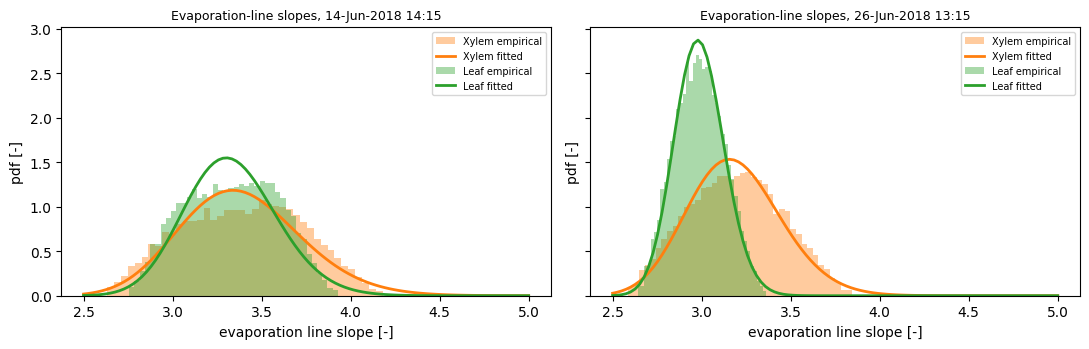

In [ ]:
nval = 10
dhr_list = np.linspace(-0.1, 0.1, nval)
dT_list = np.linspace(-3, 3, nval)
k_list = np.linspace(0.75, 1, nval)
n_list_s = np.linspace(0.75, 1, nval)   # soil/xylem aerodynamic parameter range
n_list_l = np.linspace(0.85, 1, nval)   # leaf aerodynamic parameter range
x_s = [0, 0.3]                           # evaporation/outflux ratio, soil (MATLAB uses x(end)=0.3)
x_l = [0, 1]                             # leaf (MATLAB uses x(end)=1)

iso_source = [-11, -79.6]                # reference point on the LMWL (main script line 118)
flag_method = 2                          # lake/soil reaching steady state

sel_list = [pd.Timestamp("2018-06-14 14:15"), pd.Timestamp("2018-06-26 13:15")]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
xg = np.linspace(2.5, 5, 100)
for ax, sel in zip(axes, sel_list):
    row = T.index[T["time"] == sel]
    assert len(row), f"timestamp {sel} not found in the kept samples"
    i = row[0]
    for typ, n_list, hr, Tc, x, color, label in [
            ("Xylem", n_list_s, T.loc[i, "rhmonth"] + dhr_list, T.loc[i, "Tmonth"] + dT_list, x_s, "tab:orange", "Xylem"),
            ("Leaves", n_list_l, T.loc[i, "rhday"] + dhr_list, T.loc[i, "Tday"] + dT_list, x_l, "tab:green", "Leaf")]:
        sl = montecarloCG(n_list, hr, Tc, k_list, iso_source, flag_method, x)
        pdf_fit = fit_lognormal(sl)
        ax.hist(sl, bins=40, density=True, alpha=0.4, color=color, label=f"{label} empirical")
        ax.plot(xg, pdf_fit.pdf(xg), color=color, lw=2, label=f"{label} fitted")
    ax.set_title(f"Evaporation-line slopes, {sel:%d-%b-%Y %H:%M}", fontsize=9)
    ax.set_xlabel("evaporation line slope [-]"); ax.set_ylabel("pdf [-]")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Theory example — one day, leaf vs xylem (paper Fig. 1 analogue)

`Leaf_water_source.m` lines 59–87: take the leaf and xylem samples collected on
**04-Jun-2018 13:35**, and project both back onto the LMWL (slope 8.26, intercept 11.30) with
`ngens=200` draws and a simple Normal slope distribution (μ=3.3, σ=0.3) plus sample uncertainty
`d_o_par=[0.05, 0.25, 0.8]`. If the MATLAB matrix contains replicate leaves, `d_o(1), d_o(2)`
address the **first** replicate — the port does the same and says so. Expected result: both
projections point to similar sources on the LMWL, with the leaf source more uncertain because leaf
water lies farther from the LMWL.

(日本語) 原著の理論例：2018-06-04 13:35の葉水と木部水をLMWLに投影します（ngens=200、傾きは
正規分布3.3±0.3）。複数反復がある場合はMATLABと同様に最初の反復を使用します。

In [ ]:
sel_time = pd.Timestamp("2018-06-04 13:35")
q = T["time"] == sel_time
assert q.any(), (f"no sample at {sel_time}; nearest kept timestamps: "
                 f"{T.loc[(T.time > sel_time - pd.Timedelta('2D')) & (T.time < sel_time + pd.Timedelta('2D')), 'time'].unique()[:8]}")
leaf_sample = T.loc[q & (T["Type"] == "Leaves"), ["d18O", "d2H"]]
xylem_sample = T.loc[q & (T["Type"] == "Xylem"), ["d18O", "d2H"]]
assert len(leaf_sample) and len(xylem_sample), "no leaf or xylem sample at the theory timestamp"
leaf_sample = leaf_sample.iloc[0].to_numpy()      # first replicate, as MATLAB d_o(1),d_o(2)
xylem_sample = xylem_sample.iloc[0].to_numpy()
print("leaf sample (d18O, d2H):", leaf_sample, "| xylem sample:", xylem_sample)

ngens_th, lmwl_th, sigma_H_lmwl_th, d_o_par_th = 200, [8.26, 11.30], 1, [0.05, 0.25, 0.8]
slope_pdf_th = stats.norm(3.3, 0.3)               # makedist('Normal','mu',3.3,'sigma',0.3)
A_L = source_sampler_iter(leaf_sample, d_o_par_th, lmwl_th, sigma_H_lmwl_th, slope_pdf_th, ngens_th)
A_X = source_sampler_iter(xylem_sample, d_o_par_th, lmwl_th, sigma_H_lmwl_th, slope_pdf_th, ngens_th)
print("accepted draws: leaf", np.isfinite(A_L[:, 0]).sum(), "| xylem", np.isfinite(A_X[:, 0]).sum())
print("mean source leaf  (d18O, d2H): %.2f, %.2f" % (np.nanmean(A_L[:, 0]), np.nanmean(A_L[:, 1])))
print("mean source xylem (d18O, d2H): %.2f, %.2f" % (np.nanmean(A_X[:, 0]), np.nanmean(A_X[:, 1])))

leaf sample (d18O, d2H): [  1.54 -34.48] | xylem sample: [ -8.88 -70.05]


accepted draws: leaf 200 | xylem 200
mean source leaf  (d18O, d2H): -10.32, -74.03
mean source xylem (d18O, d2H): -10.55, -75.69


The theory plot: LMWL (dashed), individual evaporation lines (thin gray, each connecting an
accepted source to its perturbed observation), the measured samples (×) and their projected sources
(△, large marker = mean). This is the paper's conceptual figure re-created from the pinned
algorithm and the real 04-Jun-2018 samples — a genuine input-vs-reference view.

(日本語) 理論例の図：LMWL（破線）、各候補の蒸発線（灰色）、実測値（×）、投影された水源（△）。
葉水の水源は木部水より不確実ですが、同方向を指します。

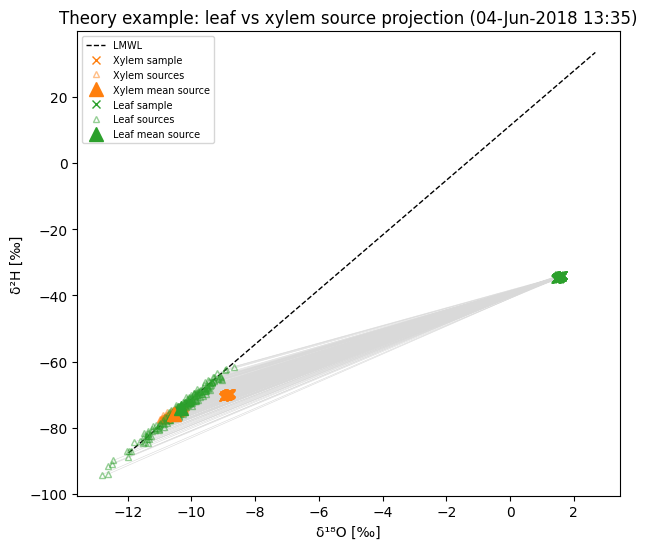

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
xx = np.array([A_X[:, 0].min() - 1, A_L[:, 2].max() + 1])
ax.plot(xx, lmwl_th[0] * xx + lmwl_th[1], "k--", lw=1, label="LMWL")
for A, color, name in [(A_X, "tab:orange", "Xylem"), (A_L, "tab:green", "Leaf")]:
    ok = np.isfinite(A[:, 0])
    for j in np.where(ok)[0]:
        ax.plot([A[j, 0], A[j, 2]], [A[j, 1], A[j, 3]], color="0.85", lw=0.4, zorder=1)
    ax.plot(A[ok, 2], A[ok, 3], "x", color=color, ms=6, label=f"{name} sample", zorder=3)
    ax.plot(A[ok, 0], A[ok, 1], "^", mfc="none", mec=color, ms=5, alpha=0.5, zorder=2,
            label=f"{name} sources")
    ax.plot(np.nanmean(A[:, 0]), np.nanmean(A[:, 1]), "^", color=color, ms=10, zorder=4,
            label=f"{name} mean source")
ax.set_xlabel("δ¹⁸O [‰]"); ax.set_ylabel("δ²H [‰]")
ax.set_title("Theory example: leaf vs xylem source projection (04-Jun-2018 13:35)")
ax.legend(fontsize=7, loc="upper left"); plt.tight_layout(); plt.show()

## Full run — project every xylem and leaf sample

Settings copied verbatim from `Leaf_water_source.m` lines 112–134: `ngens=100` accepted sources per
sample, LMWL (8.27, 11.41), `sigma_H_lmwl=1`, sample uncertainty `d_o_par=[0.12, 0.81, 0.5]`,
reference source `iso_source=[-11, -79.6]`, `flag_method=2`, 10 values per parameter (10 000
combinations). Per sample: Craig-Gordon slopes → lognormal fit → projection; store the mean slope
and the mean/std/95% width of the projected δ¹⁸O and δ²H sources. Xylem uses 30-day meteorology,
leaves 24-h meteorology.

(日本語) 全試料（100試料程度）について同様の計算を行います。木部水は30日平均、葉水は24時間平均の
気象データを使用します。数分かかります。

In [ ]:
ngens = 100
lmwl_par = [8.27, 11.41]
sigma_H_lmwl = 1
d_o_par = [0.12, 0.81, 0.5]

for col in ["sl", "mpO", "stdpO", "mpH", "stdpH", "uncpO", "uncpH"]:
    T[col] = np.nan
slope_records = []
t0 = __import__("time").time()
for i in range(len(T)):
    typ = T.loc[i, "Type"]
    if typ in ("Xylem", "Phloem"):       # soil evaporation regime (30-day meteo)
        sl = montecarloCG(n_list_s, T.loc[i, "rhmonth"] + dhr_list,
                          T.loc[i, "Tmonth"] + dT_list, k_list, iso_source, flag_method, x_s)
    elif typ == "Leaves":                # leaf evaporation regime (24-h meteo)
        sl = montecarloCG(n_list_l, T.loc[i, "rhday"] + dhr_list,
                          T.loc[i, "Tday"] + dT_list, k_list, iso_source, flag_method, x_l)
    else:
        continue
    pd_slope = fit_lognormal(sl)
    for s in sl:
        slope_records.append((T.loc[i, "time"], typ, s))
    src = source_sampler_iter([T.loc[i, "d18O"], T.loc[i, "d2H"]], d_o_par,
                              lmwl_par, sigma_H_lmwl, pd_slope, ngens)
    T.loc[i, "sl"] = np.mean(sl)
    T.loc[i, "mpO"] = np.mean(src[:, 0])       # mean projected source d18O
    T.loc[i, "stdpO"] = np.std(src[:, 0], ddof=1)
    T.loc[i, "mpH"] = np.mean(src[:, 1])
    T.loc[i, "stdpH"] = np.std(src[:, 1], ddof=1)
    T.loc[i, "uncpO"] = np.nanquantile(src[:, 0], 0.975) - np.nanquantile(src[:, 0], 0.025)
    T.loc[i, "uncpH"] = np.nanquantile(src[:, 1], 0.975) - np.nanquantile(src[:, 1], 0.025)
    if (i + 1) % 20 == 0 or i == len(T) - 1:
        print(f"sample {i + 1}/{len(T)} done ({__import__('time').time() - t0:.1f} s)", flush=True)
print("full projection finished in %.1f s" % (__import__("time").time() - t0))

sample 20/84 done (8.1 s)


sample 40/84 done (16.0 s)


sample 60/84 done (23.5 s)


sample 80/84 done (31.6 s)


sample 84/84 done (33.1 s)


full projection finished in 33.1 s


## Results

Per-sample projected sources with uncertainty, exported to CSV inside the Colab VM
(`/content/leaf_water_source_projection_results.csv`). The columns mirror the author's table `T`
(`sl` mean evaporation-line slope; `mpO/stdpO/uncpO`, `mpH/stdpH/uncpH` mean, std and 95% width of
the projected source). Values below come from this fresh run.

(日本語) 各試料の投影結果（平均・標準偏差・95%幅）を表とCSVで出力します。

In [ ]:
cols = ["time", "Type", "d18O", "d2H", "sl", "mpO", "stdpO", "uncpO", "mpH", "stdpH", "uncpH", "datecount"]
results = T[cols].copy()
results.to_csv("leaf_water_source_projection_results.csv", index=False)
print("saved /content/leaf_water_source_projection_results.csv")
results.drop(columns=["datecount"]).describe().round(2)

saved /content/leaf_water_source_projection_results.csv


,time,d18O,d2H,sl,mpO,stdpO,uncpO,mpH,stdpH,uncpH
count,84,84.00,84.00,84.00,84.00,84.00,84.00,84.00,84.00,84.00
mean,2018-06-15 01:29:05,-4.28,-57.81,3.19,-10.90,0.36,1.32,-78.62,2.58,9.57
min,2018-05-08 12:30:00,-9.79,-81.52,2.95,-12.19,0.13,0.45,-89.51,0.96,3.04
25%,2018-06-04 01:26:15,-8.90,-75.55,3.14,-11.71,0.23,0.84,-85.26,1.50,5.44
50%,2018-06-22 13:00:00,-7.82,-66.12,3.20,-11.04,0.27,0.98,-79.85,1.74,6.40
75%,2018-06-26 13:15:00,1.76,-34.31,3.29,-10.23,0.46,1.63,-73.20,3.40,12.31
max,2018-06-29 14:00:00,10.43,-11.96,3.50,-8.56,1.38,5.40,-59.34,11.37,44.59
std,NaN,6.44,21.12,0.13,0.95,0.21,0.78,7.84,1.78,6.81


Projection time series (re-creating `generate_fig_projection.m` figure 1): measured samples
(top row, before projection) and projected sources with ±1 std error bars (bottom row, after
projection) for xylem (orange) and leaves (green). Expected from the paper: the projected sources
collapse toward the LMWL region, and the leaf-source trend follows the xylem-source trend despite
larger uncertainty.

(日本語) 投影前（上段）と投影後（下段、±1σ）の時系列。葉水の水源は木部水の推移を再現し、
不確実性は大きくなります。

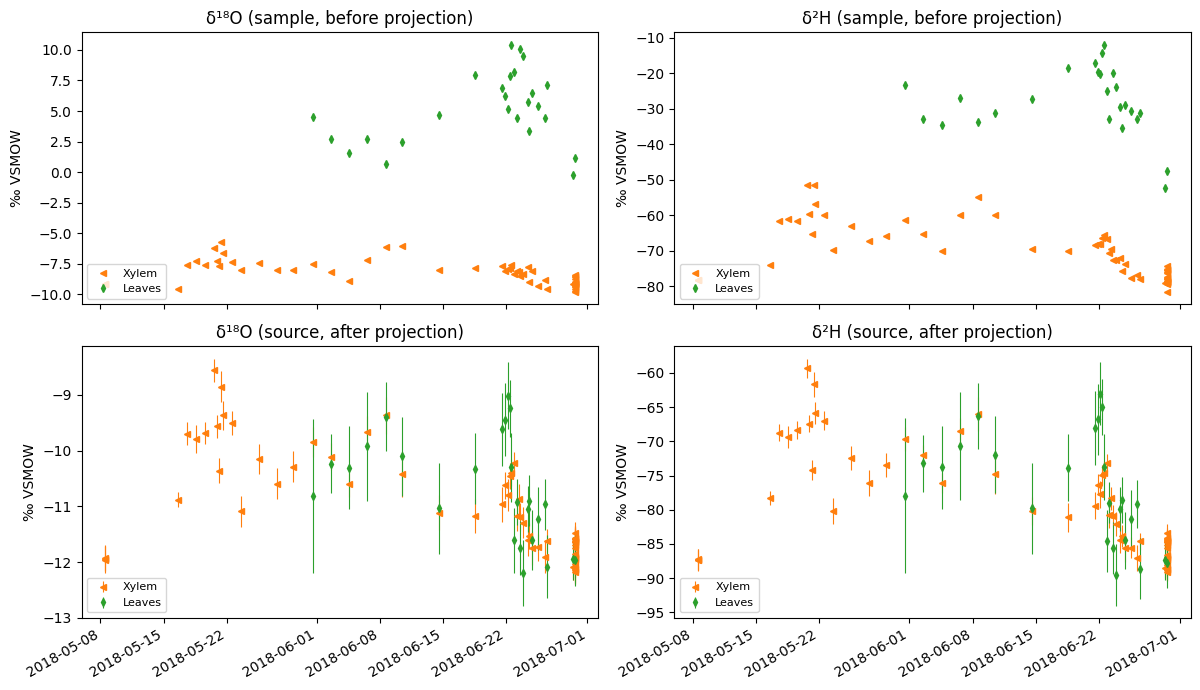

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
styles = {"Xylem": ("<", "tab:orange"), "Leaves": ("d", "tab:green")}
for typ, (mk, color) in styles.items():
    m = T["Type"] == typ
    axes[0, 0].plot(T.loc[m, "time"], T.loc[m, "d18O"], mk, ms=4, color=color, label=typ)
    axes[0, 1].plot(T.loc[m, "time"], T.loc[m, "d2H"], mk, ms=4, color=color, label=typ)
    axes[1, 0].errorbar(T.loc[m, "time"], T.loc[m, "mpO"], T.loc[m, "stdpO"], fmt=mk, ms=4,
                        color=color, elinewidth=0.8, label=typ)
    axes[1, 1].errorbar(T.loc[m, "time"], T.loc[m, "mpH"], T.loc[m, "stdpH"], fmt=mk, ms=4,
                        color=color, elinewidth=0.8, label=typ)
axes[0, 0].set_title("δ¹⁸O (sample, before projection)"); axes[0, 1].set_title("δ²H (sample, before projection)")
axes[1, 0].set_title("δ¹⁸O (source, after projection)"); axes[1, 1].set_title("δ²H (source, after projection)")
for ax in axes.flat:
    ax.set_ylabel("‰ VSMOW")
    ax.legend(fontsize=8, loc="lower left")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### Leaf-minus-xylem residuals per sampling day (paper's validation)

`Leaf_water_source.m` lines 212–236: for every sampling day from **30-May-2018** (before that only
xylem was collected) where both types exist, compute mean(leaf source) − mean(xylem source) in
δ¹⁸O and δ²H, then the mean and standard deviation of the residuals. The author's reference
(code comments and abstract): **mean ≈ 2.3‰ in δ²H; std ≈ 0.8‰ δ¹⁸O and 6.9‰ δ²H**, with an
unexplained systematic pattern around 20 June (water-stress period). Note: the Monte Carlo draws
are not seeded identically to MATLAB, so expect small (≤ ~0.5‰) deviations in these statistics.

(日本語) 2018-05-30以降の各採取日について、葉水と木部水の投影水源の差（残差）を計算します。
著者の参照値は平均≈2.3‰（δ²H）、標準偏差≈0.8‰（δ¹⁸O）・6.9‰（δ²H）です。

mean res (d18O,d2H) L-X: 0.22, 1.75
std  res (d18O,d2H) L-X: 0.76, 6.33
author reference (code comments): mean 2.3 (d2H); std 0.8 (d18O), 6.9 (d2H)


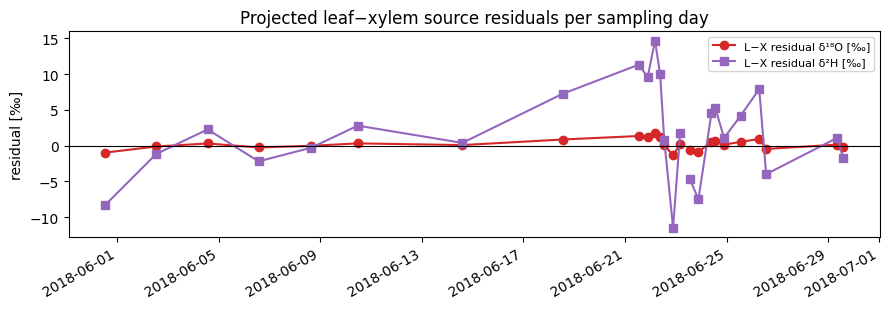

In [ ]:
q = T["time"] >= pd.Timestamp("2018-05-30")
resdays = sorted(T.loc[q, "datecount"].unique())
res = np.full((len(resdays), 2), np.nan)
res_dates = []
for nn, dc in enumerate(resdays):
    tmp1 = (T["datecount"] == dc) & (T["Type"] == "Xylem")
    tmp3 = (T["datecount"] == dc) & (T["Type"] == "Leaves")
    res_dates.append(T.loc[q & (T["datecount"] == dc), "time"].iloc[0])
    if tmp1.any() and tmp3.any():
        res[nn, 0] = T.loc[tmp3, "mpO"].mean() - T.loc[tmp1, "mpO"].mean()
        res[nn, 1] = T.loc[tmp3, "mpH"].mean() - T.loc[tmp1, "mpH"].mean()
mres, stdres = np.nanmean(res, axis=0), np.nanstd(res, axis=0, ddof=1)
print("mean res (d18O,d2H) L-X: %.2f, %.2f" % (mres[0], mres[1]))
print("std  res (d18O,d2H) L-X: %.2f, %.2f" % (stdres[0], stdres[1]))
print("author reference (code comments): mean 2.3 (d2H); std 0.8 (d18O), 6.9 (d2H)")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(res_dates, res[:, 0], "o-", color="tab:red", label="L−X residual δ¹⁸O [‰]")
ax.plot(res_dates, res[:, 1], "s-", color="tab:purple", label="L−X residual δ²H [‰]")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("residual [‰]"); ax.set_title("Projected leaf−xylem source residuals per sampling day")
ax.legend(fontsize=8); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## Interpretation, differences from the paper, and validation record

**What this notebook shows (this run, CPU Colab):** every xylem and leaf sample of the released
SPIKE II dataset was projected onto the LMWL through the author's full Craig-Gordon + rejection
sampler pipeline; leaf and xylem projected sources were compared per sampling day from 30 May 2018.

**Comparison with the author's reported values** — see the printed residual statistics above and
the evaporation-slope sanity check (author: slopes mostly 3.1–3.5). Deviations beyond Monte Carlo
noise would appear here; the residuals plot should show the same overall behavior as the paper,
including the systematic pattern around 20 June that the authors could not explain (water stress).

**Differences / adaptations:**
- AI-assisted **MATLAB → Python translation** (commit `c495e14`); equations copied verbatim.
  RNG streams differ from MATLAB (author code is unseeded; we seed NumPy for reproducibility), so
  Monte Carlo statistics deviate slightly by construction.
- `generate_fig_theory.m` was not fetched; the theory plot is re-created from the settings in
  `Leaf_water_source.m` (lines 59–87) and the same sampler.
- The paper's full text was not retrievable (Wiley 403 during investigation); every scientific
  parameter used here comes from the pinned author code, which the paper's README ties to this DOI.

**Not verified here:** dataset-level accuracy claims, the sampling-design details described only
in the paper body, and byte-equality between the Zenodo isotope file and any other version
(the Zenodo MD5 and the repo blob hash are verified against pinned metadata instead).

**References:** Benettin et al. (2021) doi:10.1002/hyp.14073 · code
github.com/pbenettin/Leaf_water_source @ c495e14 (MIT) · data Zenodo doi:10.5281/zenodo.4037240
(CC-BY-4.0) · Craig & Gordon (1965) · Horita & Wesolowski (1994) · Merlivat (1978) ·
Gonfiantini (1986) · Gibson et al. (2008, 2016) · Bowen et al. (2018) Oecologia
(github.com/SPATIAL-Lab/watercompare).

(日本語) 本notebookは著者コードの忠実な移植に基づく部分的な再現です。モンテカルロの乱数系列は
MATLABと異なるため統計量は多少ずれます。論文本文は未取得のため、科学パラメータはすべて
ピン止めした著者コード由来です。